# Run Basic RNN on TAM task

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# System imports
from pathlib import Path
import sys
from datetime import date
from collections import defaultdict

# Plotting imports
import matplotlib.pyplot as plt
import seaborn as sns

# Scientific imports
import numpy as np

# NN imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
SRC_PATH = ROOT / 'src'
sys.path.append(str(ROOT))
sys.path.append(str(SRC_PATH))

# Custom imports
from src.environments import TAMTask, visualize_environment
from src.networks import TAMNet
from src.utils import load_params

In [3]:
# Set the seaborn theme
sns.set_theme(
    font_scale=1,
    style='white',
    context='poster',
    # font='Segoe UI',
)

## 0. Basic settings

In [1]:
%matplotlib inline

In [2]:
# Set directories
# Save figures
today = date.today().strftime('%m-%d-%Y')
FIG_DIR = ROOT / 'figures' / today
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Save network
MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Load parameters
params = load_params(str(ROOT / 'parameters.json'))
exp_params = params["EXPERIMENT"]

NameError: name 'date' is not defined

## 1. Task environments

In [34]:
# Load parameters
env_params = params['TASK']

# Create environments and datasets
env_types = [
    "normal-horizontal",
    "normal-vertical",
    "outline-horizontal",
    "outline-vertical",
    "disjoint-horizontal",
    "disjoint-vertical"
]

datasets = defaultdict()

for et in env_types:
    env = TAMTask(
        dt=env_params["dt"],
        stim_type=et,
        sigma=env_params["sigma"],
        img_size=env_params["img_size"]
    )
    env.reset(no_step=True)

    # Generate dataset object
    dataset = ngym.Dataset(
        env,
        batch_size=env_params["batch_size"],
        seq_len=env_params["sequence_length"]
    )

    # Add dataset to dictionary
    datasets[et] = dataset

findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

KeyboardInterrupt: 

findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI' not found.
findfont: Font family 'Segoe UI'

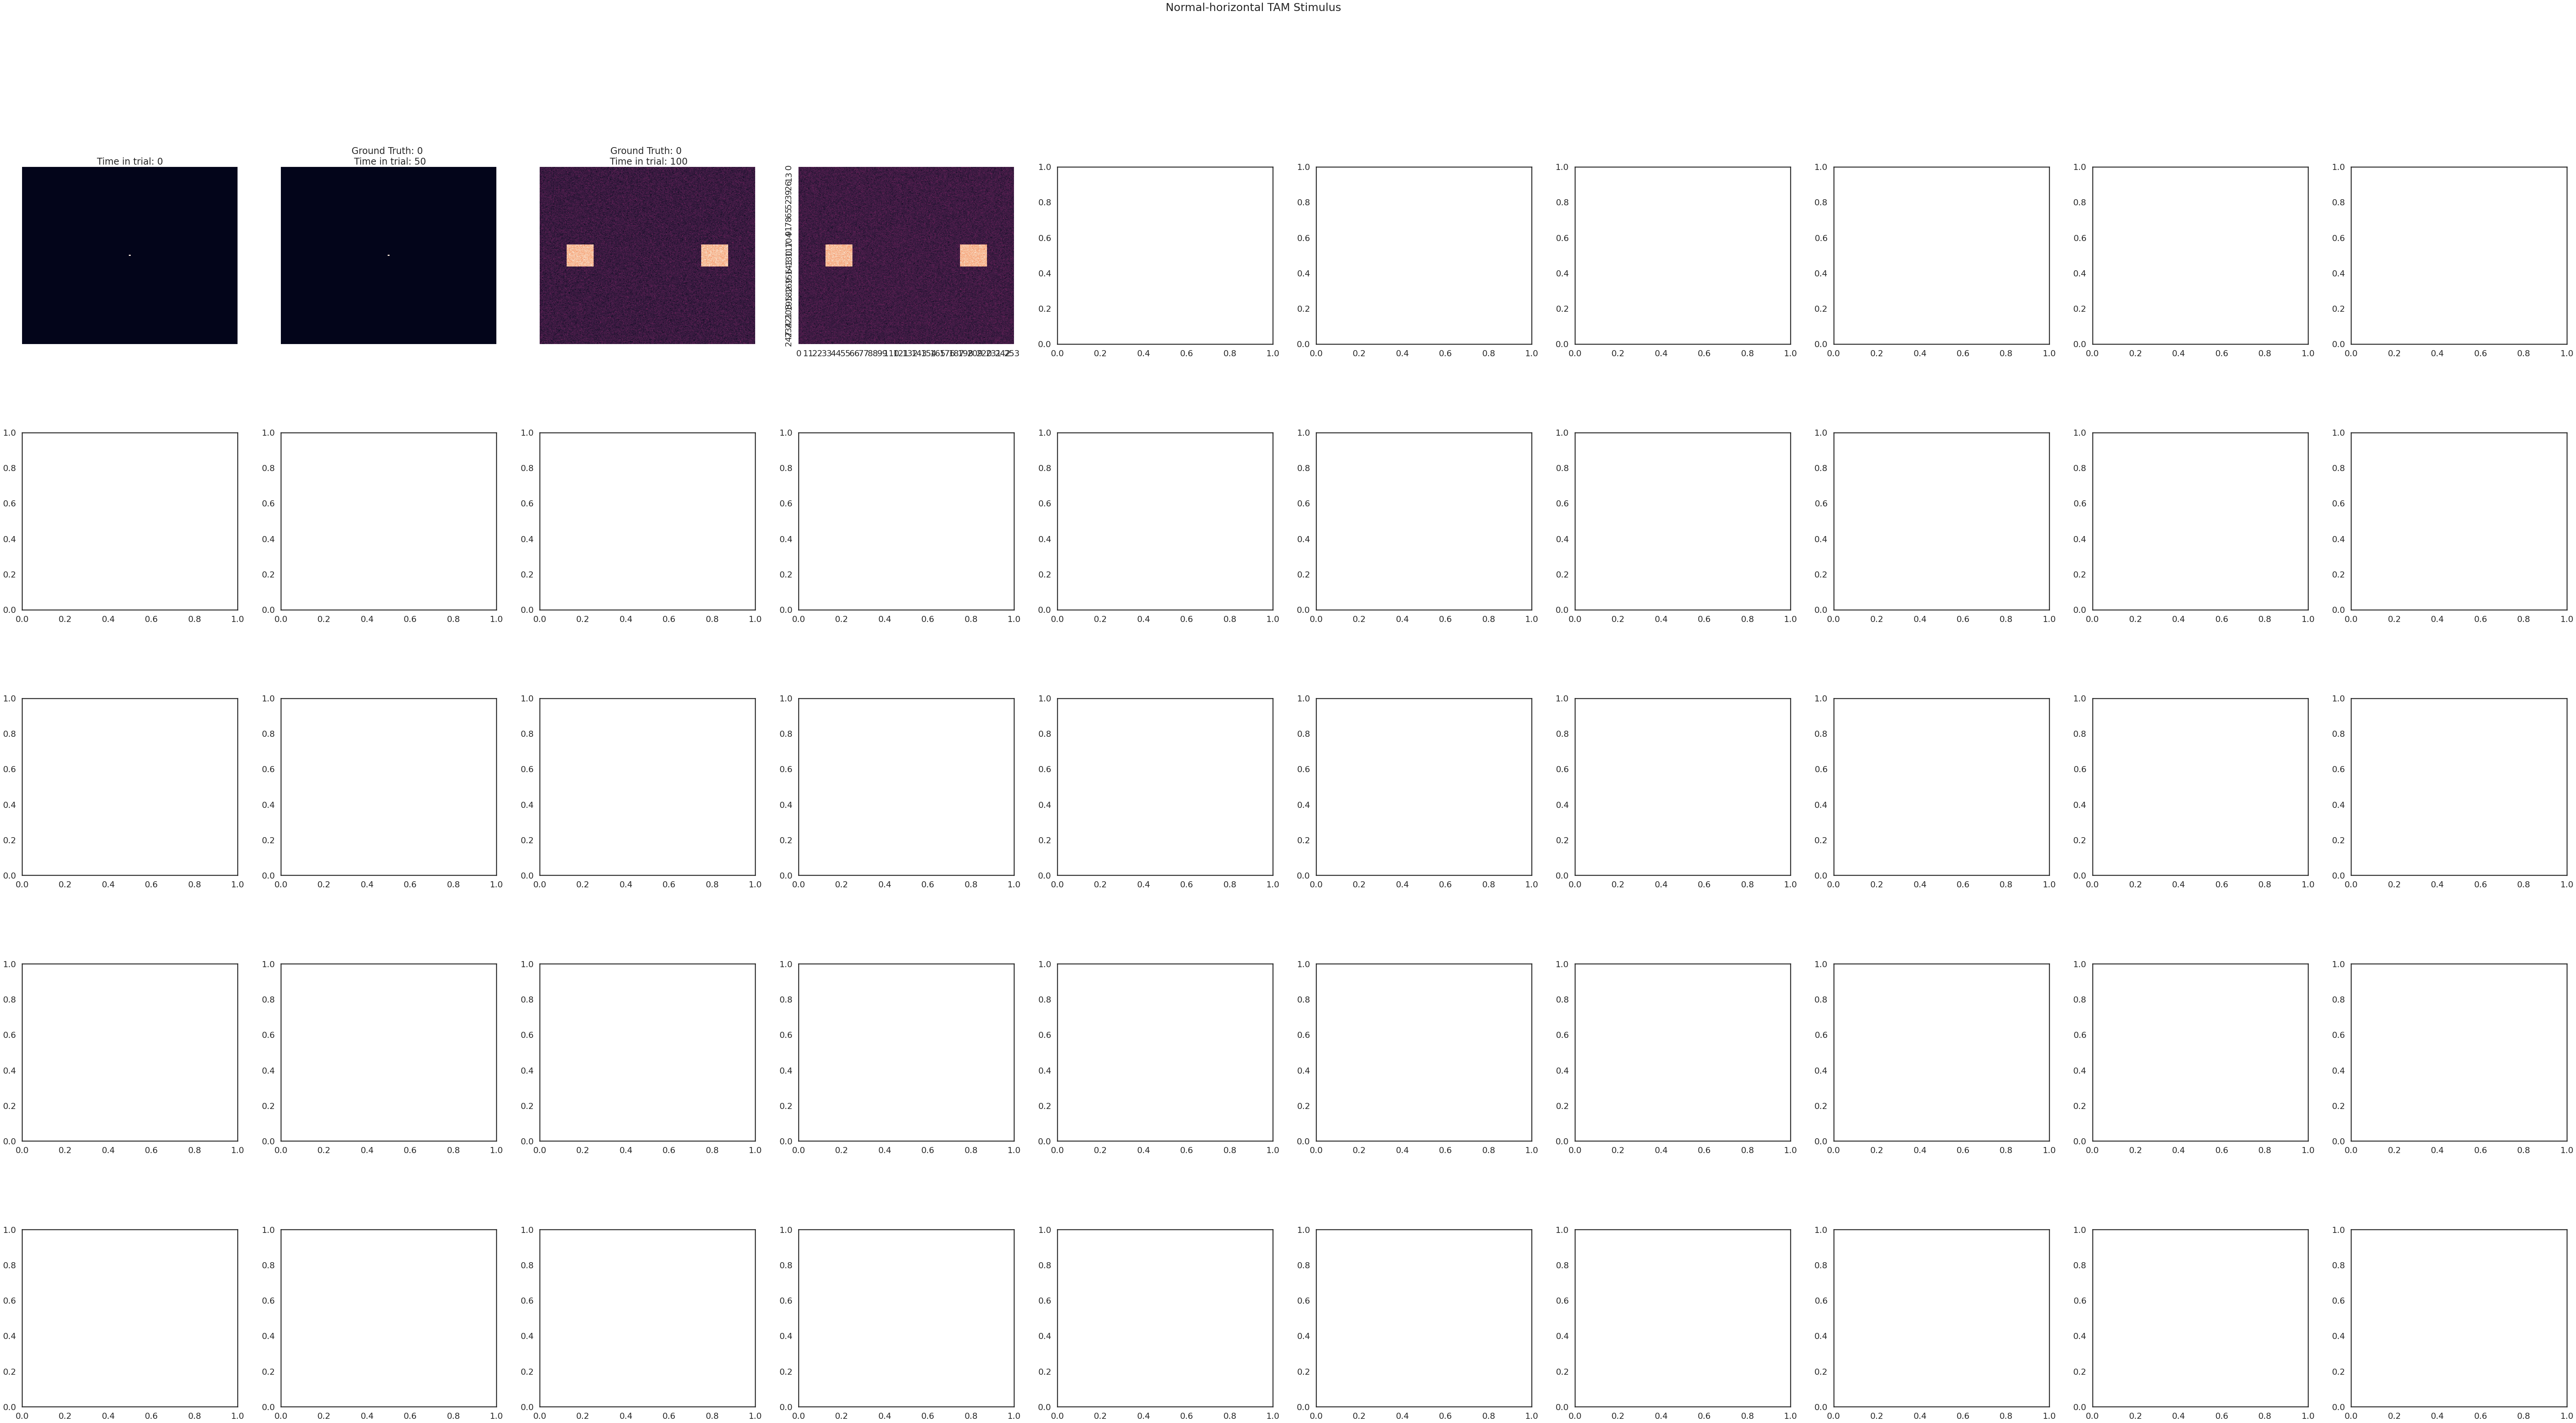

In [34]:
# Visualize environments
for et in env_types:
    _ = visualize_environment(datasets[et].env, n_trials=5, save_dir=str(FIG_DIR / f'{et}_TAM_sample_trials.png'))

In [35]:
# Look at the shapes of the datasets
inputs, target = datasets["normal-horizontal"]()
print('Input has shape (SeqLen, Batch, C, W, H) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Targets in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, C, W, H) = (100, 64, 3, 64, 64)
Target has shape (SeqLen, Batch) = (100, 64)
Targets in the first sequence:
[0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 2
 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 3 3 3 3 0 0 0 0
 0 0 1 1 1 1 0 0 0 0 0 0 2 2 2 2 0 0 0 0 0 0 1 1 1 1]


## 2. Train network

In [41]:
# Load parameters
net_params = params['NETWORK']
device = torch.device(exp_params["device"])
# device = torch.device('cpu')

# Create network to train on the normal stimuli
train_dataset = datasets["normal-horizontal"]
net = TAMNet(
    dataset=train_dataset,
    hidden_size=net_params["hidden_size"],
    output_size=train_dataset.env.action_space.n,
    learning_rate=net_params["learning_rate"],
    device=device
)

In [42]:
# Train network
train_loss, train_acc = net.train_rnn(
    datasets=[datasets["normal-horizontal"], datasets["normal-vertical"]],
    n_epochs=net_params["n_epochs"]
)

Training started...
Step 100, Loss 0.1358, Time 208.9s
Step 200, Loss 0.0008, Time 419.6s


In [26]:
vert_train_loss, vert_train_acc = net.train_rnn(dataset=datasets["normal-vertical"])

Training started...
Step 100, Loss 3.1271, Time 27.5s
Step 200, Loss 0.0004, Time 55.3s


In [43]:
trained_rnn = net.RNN

In [15]:
# save network
torch.save(trained_rnn.state_dict(), MODEL_DIR / f'TAMNet_basic_normal_{today}_{env_params["img_size"]}.pt')

In [44]:
trained_rnn.eval()

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=12288, out_features=128, bias=True)
    (h2h): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [25]:
# Put network back in learning mode
trained_rnn.train()


RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=12288, out_features=128, bias=True)
    (h2h): Linear(in_features=128, out_features=128, bias=True)
  )
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

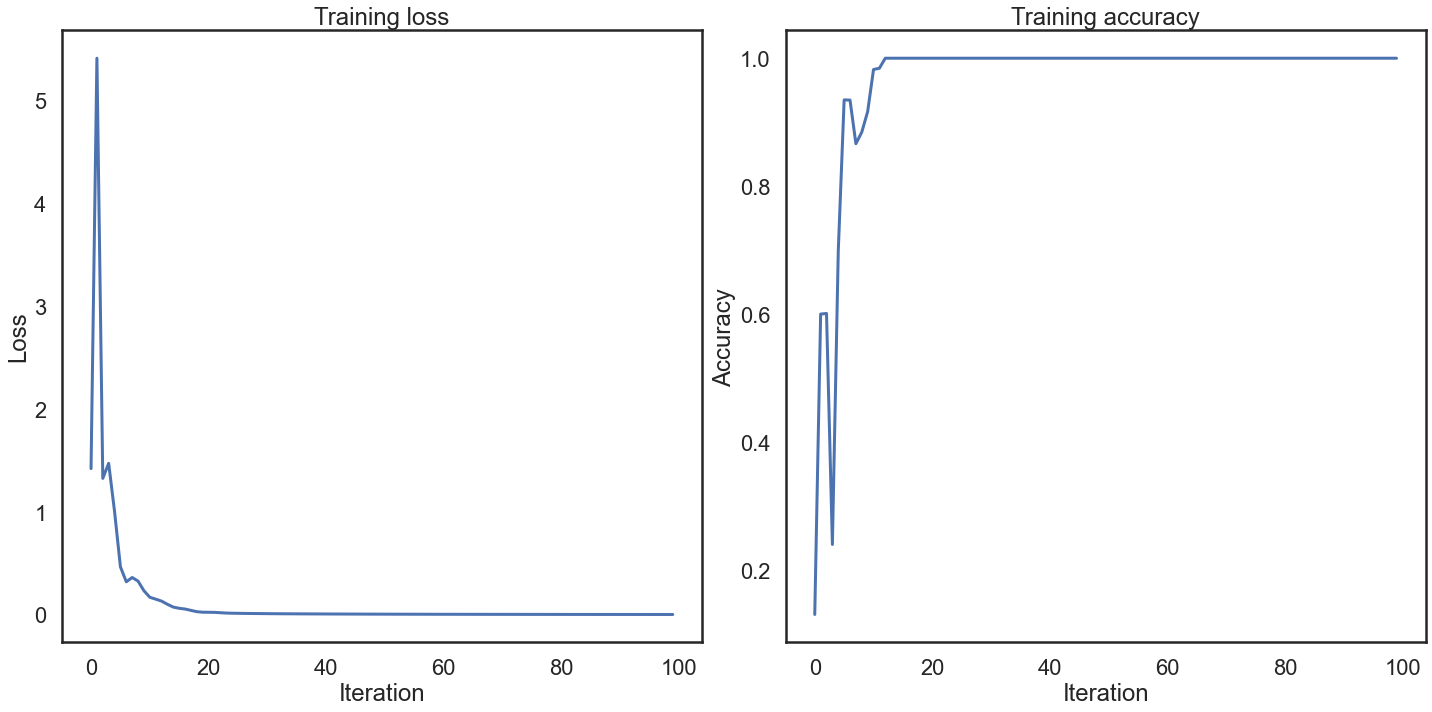

In [45]:
# Plot training curves
def plot_training_curve():
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    ax[0].plot(train_loss[:100])
    ax[0].set_xlabel('Iteration')
    ax[0].set_ylabel('Loss')
    ax[0].set_title('Training loss')
    ax[1].plot(train_acc[:100])
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title('Training accuracy')
    plt.tight_layout()
    # plt.savefig(FIG_DIR / 'TAMNet_basic_normal_training_curves.png')
    plt.show()

plot_training_curve()

In [46]:
# Test on other environments
for et in env_types:
    test_dataset = datasets[et]
    test_acc = net.test_rnn(100, test_dataset)
    print(f'Accuracy on {et} = {test_acc[-1]}')

Accuracy on normal-horizontal = 1.0
Accuracy on normal-vertical = 1.0
Accuracy on outline-horizontal = 1.0
Accuracy on outline-vertical = 1.0
Accuracy on disjoint-horizontal = 0.29
Accuracy on disjoint-vertical = 0.31
